In [ ]:
!pip install -q --no-warn-conflicts \
transformers accelerate datasets evaluate rouge-score \
sentence-transformers nltk sentencepiece scikit-learn \
matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.1 MB/s eta 0:00:00:00:010:01


In [ ]:
import os, gc, re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)
from evaluate import load
import nltk
from tqdm import tqdm
from sklearn.model_selection import train_test_split

nltk.download('punkt', quiet=True)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"]   = "false"
torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU — training will be slow.")

gc.collect()
torch.cuda.empty_cache()
print(f"Device: {device}")

GPU : Tesla T4
VRAM: 15.6 GB
Device: cuda


In [ ]:
def clean_text(text: str) -> str:
    """Clean raw OCR / scraped lecture text."""
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    for bad, good in {
        'ﬁ': 'fi', 'ﬂ': 'fl', '—': '-', '–': '-',
        '\u2018': "'", '\u2019': "'", '\u201c': '"', '\u201d': '"', '…': '...',
    }.items():
        text = text.replace(bad, good)

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    text = re.sub(r'[-\s]*\bpage\s*\d+\b[-\s]*', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'(?m)^\s*\d{1,4}\s*$', '', text)

    lines, cleaned = text.split('\n'), []
    for line in lines:
        s = line.strip()
        if not s:                                    cleaned.append('')
        elif len(s) <= 2 and not s.isalnum():        continue
        elif re.match(r'^[•\-*_=]+$', s):           continue
        else:                                        cleaned.append(line)
    text = '\n'.join(cleaned)

    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)

    sentences, seen, unique = re.split(r'(?<=[.!?])\s+', text), set(), []
    for sent in sentences:
        norm = re.sub(r'[^\w\s]', '', sent.strip().lower())
        if norm and norm not in seen:
            seen.add(norm); unique.append(sent.strip())
    return ' '.join(unique).strip()


def format_text(text: str) -> str:
    text = re.sub(r'(?<!\n)\n([A-Z][A-Za-z\s]+:)\n', r'\n\n\1\n', text)
    text = re.sub(r'^[•▪▸➢]\s*', '- ', text, flags=re.MULTILINE)
    text = re.sub(r'(\d+)\.(\S)', r'\1. \2', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

In [ ]:
import os
import pandas as pd


DATA_PATH = "/kaggle/input/datasets/yahyamarae/data-gp/TextSummarization_Data/DATA"

texts, summaries, subjects = [], [], []

print("Loading data …")

for subject in os.listdir(DATA_PATH):
    subject_path = os.path.join(DATA_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    text_dir = os.path.join(subject_path, "Text")
    summary_dir = os.path.join(subject_path, "Summary")
    if not (os.path.exists(text_dir) and os.path.exists(summary_dir)):
        continue

    for fname in os.listdir(text_dir):
        tpath = os.path.join(text_dir, fname)
        spath = os.path.join(summary_dir, fname)
        if not os.path.exists(spath):
            continue
        try:
            with open(tpath, 'r', encoding='utf-8', errors='ignore') as f:
                raw_text = f.read().strip()
            with open(spath, 'r', encoding='utf-8', errors='ignore') as f:
                raw_sum = f.read().strip()
            if raw_text and raw_sum:
                texts.append(format_text(clean_text(raw_text)))
                summaries.append(clean_text(raw_sum))
                subjects.append(subject)
        except Exception:
            continue

df = pd.DataFrame({
    "text": texts,
    "summary": summaries,
    "subject": subjects
})
df["text_words"] = df["text"].apply(lambda x: len(x.split()))
df["summary_words"] = df["summary"].apply(lambda x: len(x.split()))

print(f"   Loaded {len(df)} samples")
print(f"   Avg text length   : {df['text_words'].mean():.0f} words")
print(f"   Avg summary length: {df['summary_words'].mean():.0f} words")
print(f"   Unique subjects   : {df['subject'].nunique()}")

Loading data …
   Loaded 405 samples
   Avg text length   : 2992 words
   Avg summary length: 504 words
   Unique subjects   : 37


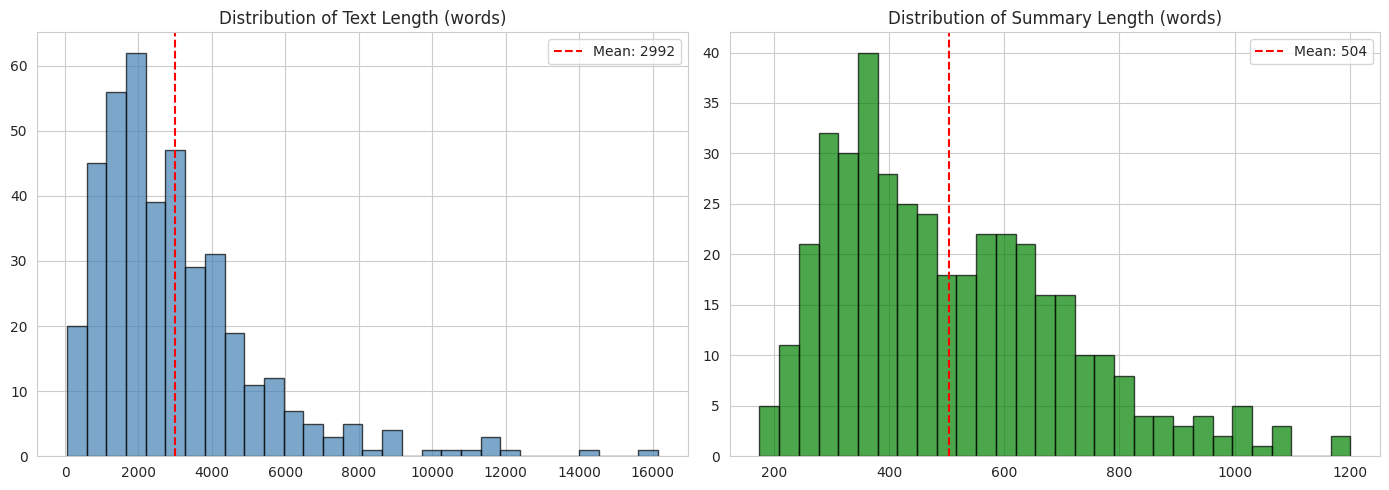

/tmp/ipykernel_58/3701292542.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sc.values, y=sc.index, palette="viridis")


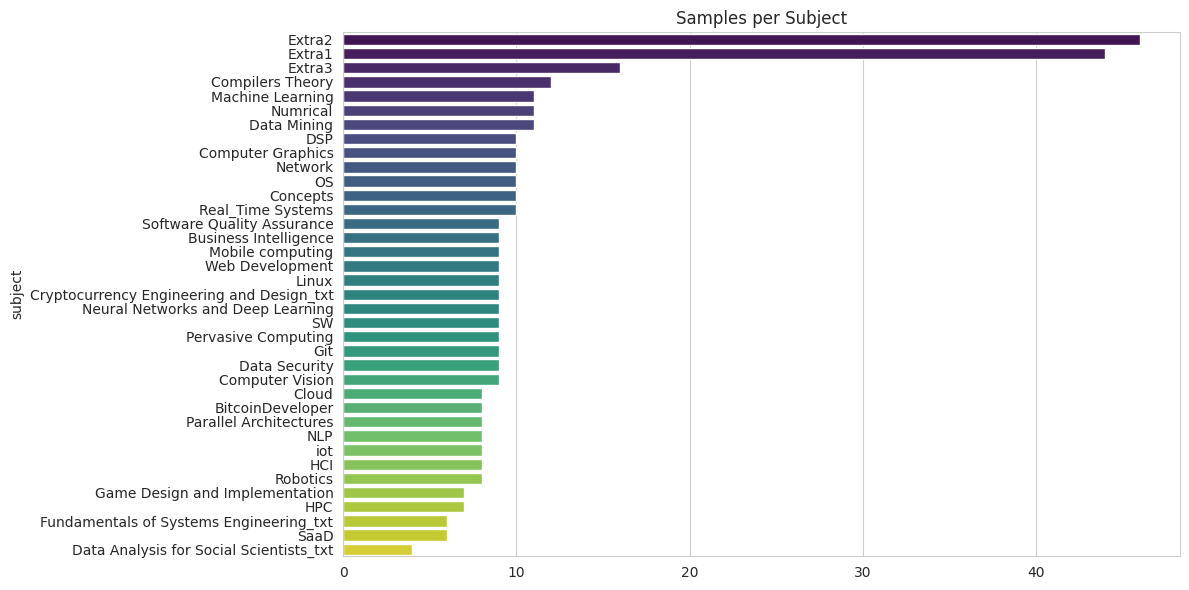

In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, label in [
    (axes[0], "text_words",    "steelblue", "Text"),
    (axes[1], "summary_words", "green",     "Summary"),
]:
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7, color=color)
    ax.set_title(f"Distribution of {label} Length (words)")
    ax.axvline(df[col].mean(), color='red', linestyle='dashed',
               label=f'Mean: {df[col].mean():.0f}')
    ax.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 6))
sc = df["subject"].value_counts()
sns.barplot(x=sc.values, y=sc.index, palette="viridis")
plt.title("Samples per Subject"); plt.tight_layout(); plt.show()

In [ ]:
from rouge_score import rouge_scorer
import numpy as np

print("\n" + "="*60)
print("           DATASET QUALITY EVALUATION")
print("="*60)


avg_text_len = df["text_words"].mean()
avg_summary_len = df["summary_words"].mean()

compression_ratio = (
    df["summary_words"] / df["text_words"]
).mean()

print(f"Number of samples        : {len(df)}")
print(f"Average text length      : {avg_text_len:.1f} words")
print(f"Average summary length   : {avg_summary_len:.1f} words")
print(f"Compression ratio        : {compression_ratio:.3f} ({compression_ratio*100:.1f}%)")


duplicate_texts = df["text"].duplicated().sum()
duplicate_summaries = df["summary"].duplicated().sum()

print(f"\nDuplicate texts          : {duplicate_texts}")
print(f"Duplicate summaries      : {duplicate_summaries}")


def coverage_score(source, summary):
    src_words = set(source.lower().split())
    sum_words = set(summary.lower().split())

    if len(sum_words) == 0:
        return 0

    return len(src_words & sum_words) / len(sum_words)

coverage_scores = [
    coverage_score(src, summ)
    for src, summ in zip(df["text"], df["summary"])
]

avg_coverage = np.mean(coverage_scores)

print(f"\nAverage coverage score   : {avg_coverage:.4f}")


scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rougeL'],
    use_stemmer=True
)

rouge1_scores = []
rougeL_scores = []

for src, summ in zip(df["text"], df["summary"]):

    score = scorer.score(src, summ)

    rouge1_scores.append(score["rouge1"].fmeasure)
    rougeL_scores.append(score["rougeL"].fmeasure)

print(f"\nAverage Source→Summary ROUGE-1 : {np.mean(rouge1_scores):.4f}")
print(f"Average Source→Summary ROUGE-L : {np.mean(rougeL_scores):.4f}")


print("\nSummary Length Statistics")
print(f"Min summary words : {df['summary_words'].min()}")
print(f"Max summary words : {df['summary_words'].max()}")
print(f"Std deviation     : {df['summary_words'].std():.1f}")


print("\nDATASET HEALTH CHECK")

if duplicate_texts < len(df) * 0.05:
    print("PASS Low duplicate text rate")
else:
    print("WARN High duplicate text rate")

if duplicate_summaries < len(df) * 0.05:
    print("PASS Low duplicate summary rate")
else:
    print("WARN High duplicate summary rate")

if compression_ratio < 0.30:
    print("PASS Good compression ratio")
else:
    print("WARN Summaries may be too long")

if avg_coverage > 0.60:
    print("PASS Good source-summary coverage")
else:
    print("WARN Low coverage; summaries may be loosely related")

print("="*60)


           DATASET QUALITY EVALUATION
Number of samples        : 405
Average text length      : 2992.1 words
Average summary length   : 503.9 words
Compression ratio        : 0.272 (27.2%)

Duplicate texts          : 1
Duplicate summaries      : 0

Average coverage score   : 0.5762

Average Source→Summary ROUGE-1 : 0.2975
Average Source→Summary ROUGE-L : 0.2091

Summary Length Statistics
Min summary words : 175
Max summary words : 1201
Std deviation     : 200.6

DATASET HEALTH CHECK
PASS Low duplicate text rate
PASS Low duplicate summary rate
PASS Good compression ratio
WARN Low coverage; summaries may be loosely related


In [ ]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df_shuffled, test_size=0.2, random_state=42, shuffle=False)
val_df,   test_df = train_test_split(temp_df,      test_size=0.5, random_state=42, shuffle=False)
print(f"Train={len(train_df)}  Val={len(val_df)}  Test={len(test_df)}")

Train=324  Val=40  Test=41


In [ ]:
MODEL_NAME = "facebook/bart-large-cnn"

print(f"Loading {MODEL_NAME} …")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)

use_bf16 = device == "cuda" and torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16 and device == "cuda"

model = BartForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype = torch.bfloat16 if use_bf16 else
                  torch.float16  if use_fp16 else
                  torch.float32,
).to(device)

model.gradient_checkpointing_enable()
model.config.use_cache = False

print(f"   Loaded  |  Params: {model.num_parameters()/1e6:.0f} M")
print(f"   Precision → bf16={use_bf16}  fp16={use_fp16}")


Loading facebook/bart-large-cnn …


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

   Loaded  |  Params: 406 M
   Precision → bf16=True  fp16=False


In [ ]:
ENCODER_MAX  = 1024   
CHUNK_OVERLAP = 100
SUMMARY_MAX  = 256

def chunk_text(text: str) -> list:
    """Split long lecture into overlapping token-level chunks."""
    ids   = tokenizer.encode(text, add_special_tokens=False)
    step  = ENCODER_MAX - CHUNK_OVERLAP
    chunks = []
    for start in range(0, len(ids), step):
        chunk_ids = ids[start : start + ENCODER_MAX]
        if len(chunk_ids) < 30:
            continue
        chunks.append(tokenizer.decode(chunk_ids, skip_special_tokens=True))
    return chunks if chunks else [text]


def combine_summaries(parts: list) -> str:
    """Merge chunk-level summaries and remove duplicate sentences."""
    combined = "\n\n".join(parts)
    seen, unique = set(), []
    for line in combined.split('\n'):
        key = line.strip().lower()
        if key and key not in seen:
            seen.add(key); unique.append(line)
    return '\n'.join(unique)


In [ ]:
def build_chunked_dataset(split_df: pd.DataFrame) -> Dataset:
    rows = []
    for _, row in split_df.iterrows():
        for chunk in chunk_text(row['text']):
            rows.append({
                "text"   : chunk,
                "summary": row['summary'],
                "subject": row['subject'],
            })
    return Dataset.from_list(rows)

print("Building chunked datasets …")
train_hf = build_chunked_dataset(train_df)
val_hf   = build_chunked_dataset(val_df)
print(f"Train chunks: {len(train_hf)}  |  Val chunks: {len(val_hf)}")


Building chunked datasets …
Train chunks: 1842  |  Val chunks: 220


In [ ]:
def tokenize_fn(batch):
    model_inputs = tokenizer(
        batch["text"],
        max_length = ENCODER_MAX,
        truncation = True,
        padding    = False,
    )
    labels = tokenizer(
        text_target = batch["summary"],
        max_length  = SUMMARY_MAX,
        truncation  = True,
        padding     = False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

remove_cols     = ["text", "summary", "subject"]
tokenized_train = train_hf.map(tokenize_fn, batched=True, remove_columns=remove_cols)
tokenized_val   = val_hf.map(tokenize_fn,   batched=True, remove_columns=remove_cols)

print(f"Tokenised train: {len(tokenized_train)}  |  val: {len(tokenized_val)}")

Map:   0%|          | 0/1842 [00:00<?, ? examples/s]

Map:   0%|          | 0/220 [00:00<?, ? examples/s]

Tokenised train: 1842  |  val: 220


In [ ]:
import subprocess
subprocess.run(["pip", "install", "-q", "rouge_score"], check=True)

from evaluate import load
import numpy as np
from transformers import EarlyStoppingCallback

rouge_metric = load("rouge")


training_args = Seq2SeqTrainingArguments(
    output_dir="/kaggle/working/bart-lecture-tmp",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,

    num_train_epochs=15,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,

    logging_strategy="epoch",
    eval_strategy="epoch",

    save_strategy="epoch",
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="eval_rougeL",
    greater_is_better=True,

    fp16=use_fp16,
    bf16=use_bf16,

    predict_with_generate=True,
    generation_max_length=SUMMARY_MAX,
    generation_num_beams=6,

    report_to="none",

    dataloader_num_workers=2,
    max_grad_norm=1.0,
    optim="adamw_torch",
    label_smoothing_factor=0.1
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",
    label_pad_token_id=-100,
)


def compute_metrics(eval_pred):
    preds, labels = eval_pred

    preds = np.array(preds, dtype=np.int32)
    labels = np.array(labels, dtype=np.int32)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    vocab_size = tokenizer.vocab_size
    preds = np.clip(preds, 0, vocab_size - 1)
    labels = np.clip(labels, 0, vocab_size - 1)

    decoded_preds = tokenizer.batch_decode(
        preds.tolist(),
        skip_special_tokens=True
    )

    decoded_labels = tokenizer.batch_decode(
        labels.tolist(),
        skip_special_tokens=True
    )

    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    rouge_result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )

    def token_f1(pred, ref):
        pt, rt = pred.lower().split(), ref.lower().split()

        common = set(pt) & set(rt)
        if not common:
            return 0.0

        p = len(common) / len(pt)
        r = len(common) / len(rt)

        return 2 * p * r / (p + r)

    f1_scores = [
        token_f1(p, r)
        for p, r in zip(decoded_preds, decoded_labels)
    ]

    return {
        "rouge1": round(rouge_result["rouge1"], 4),
        "rouge2": round(rouge_result["rouge2"], 4),
        "rougeL": round(rouge_result["rougeL"], 4),
        "rougeLsum": round(rouge_result["rougeLsum"], 4),
        "f1": round(np.mean(f1_scores), 4),
    }


trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.0001
        )
    ],
)

print("▶ Starting BART fine-tuning ...")

trainer.train()

trainer.save_model("/kaggle/working/bart-lecture-best")
tokenizer.save_pretrained("/kaggle/working/bart-lecture-best")

torch.save(
    model.state_dict(),
    "/kaggle/working/bart_best_weights.pt"
)

print("Best model saved to /kaggle/working/bart-lecture-best")
print("Best weights saved to /kaggle/working/bart_best_weights.pt")

▶ Starting BART fine-tuning ...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,F1
1,88.984064,5.182410,0.200100,0.039100,0.120700,0.163900,0.101300
2,84.970232,4.823349,0.214800,0.042400,0.126000,0.174700,0.106100
3,77.258638,4.396717,0.288300,0.070000,0.162400,0.248500,0.134100
4,71.058863,4.230766,0.321000,0.081100,0.177300,0.284000,0.149900
5,68.352670,4.174146,0.326100,0.082200,0.180800,0.288700,0.153500
6,67.042379,4.153595,0.322600,0.085200,0.183700,0.285800,0.151400
7,66.190594,4.138514,0.325400,0.085900,0.186700,0.290900,0.153900
8,65.647377,4.130047,0.329500,0.086200,0.186300,0.293100,0.152300
9,65.202654,4.126199,0.329900,0.088000,0.188600,0.295300,0.155100
10,64.924619,4.119469,0.331500,0.089500,0.187400,0.295600,0.155200


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to /kaggle/working/bart-lecture-best
Best weights saved to /kaggle/working/bart_best_weights.pt


In [ ]:
import os
import json
import zipfile
import torch

save_path = "/kaggle/working/bart-lecture-best"

print(f"Saving model to {save_path} ...")


os.makedirs(save_path, exist_ok=True)


model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)


torch.save(
    model.state_dict(),
    os.path.join(save_path, "bart_best_weights.pt")
)


with open(
    os.path.join(save_path, "training_args.json"),
    "w"
) as f:
    json.dump(
        training_args.to_dict(),
        f,
        indent=4
    )


zip_path = "/kaggle/working/bart-lecture-best.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(save_path):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, save_path)
            zipf.write(file_path, arcname)

print("\nModel saved successfully!")
print(f"Model folder : {save_path}")
print(f"ZIP file     : {zip_path}")

print("\nSaved files:")
for file in os.listdir(save_path):
    print(" -", file)

print("\nDownload the ZIP file from Kaggle Output panel.")

Saving model to /kaggle/working/bart-lecture-best ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved successfully!
Model folder : /kaggle/working/bart-lecture-best
ZIP file     : /kaggle/working/bart-lecture-best.zip

Saved files:
 - config.json
 - model.safetensors
 - training_args.json
 - generation_config.json
 - bart_best_weights.pt
 - tokenizer.json
 - tokenizer_config.json
 - training_args.bin

Download the ZIP file from Kaggle Output panel.


In [24]:
import os

zip_path = "/kaggle/working/bart-lecture-best.zip"

print("Exists:", os.path.exists(zip_path))
print("Size GB:", round(os.path.getsize(zip_path)/(1024**3), 2))

Exists: True
Size GB: 1.2


In [25]:
import os

print(os.path.exists("/kaggle/working/bart-lecture-best"))
print(os.path.exists("/kaggle/working/bart-lecture-best.zip"))

True
True


In [26]:
import shutil

shutil.rmtree("/kaggle/working/bart-lecture-tmp", ignore_errors=True)

print("bart-lecture-tmp deleted")

bart-lecture-tmp deleted


In [27]:
import os
print(os.listdir("/kaggle/working"))

['bart-lecture-best', '.virtual_documents', 'bart_best_weights.pt', 'bart-lecture-best.zip']


In [28]:
import os

print(os.path.exists('/kaggle/working/bart-lecture-best.zip'))

True


In [29]:
from IPython.display import display, FileLink

display(FileLink('/kaggle/working/bart-lecture-best.zip'))

/kaggle/working/bart-lecture-best.zip

In [30]:
import shutil
import os

src = "/kaggle/working/bart-lecture-best.zip"
dst = "/kaggle/working/model_backup.zip"

shutil.copy2(src, dst)

print("Done")
print("Size:", round(os.path.getsize(dst)/(1024**3),2), "GB")

Done
Size: 1.2 GB


In [ ]:
print("\n" + "═"*55)
print("       📊  FINAL EVALUATION METRICS REPORT")
print("═"*55)

# Pull the last logged eval metrics from trainer state
last_metrics = {}
for log in reversed(trainer.state.log_history):
    if "eval_rouge1" in log:
        last_metrics = log
        break

metric_labels = {
    "eval_rouge1"   : "ROUGE-1",
    "eval_rouge2"   : "ROUGE-2",
    "eval_rougeL"   : "ROUGE-L",
    "eval_rougeLsum": "ROUGE-Lsum",
    "eval_f1"       : "Token F1",
    "eval_loss"     : "Eval Loss",
}

for key, label in metric_labels.items():
    value = last_metrics.get(key, None)
    if value is not None:
        print(f"   {label:<18}: {value:.4f}")

print("═"*55)

# ── Per-epoch table ───────────────────────────────────────────
print("\n📈  METRICS PER EPOCH:\n")
print(f"  {'Epoch':<8} {'ROUGE-1':<10} {'ROUGE-2':<10} {'ROUGE-L':<10} {'ROUGE-Lsum':<13} {'F1':<10} {'Loss':<10}")
print(f"  {'─'*7:<8} {'─'*7:<10} {'─'*7:<10} {'─'*7:<10} {'─'*10:<13} {'─'*7:<10} {'─'*7:<10}")

for log in trainer.state.log_history:
    if "eval_rouge1" in log:
        epoch  = log.get("epoch",          "?")
        r1     = log.get("eval_rouge1",    0)
        r2     = log.get("eval_rouge2",    0)
        rl     = log.get("eval_rougeL",    0)
        rlsum  = log.get("eval_rougeLsum", 0)
        f1     = log.get("eval_f1",        0)
        loss   = log.get("eval_loss",      0)
        print(f"  {epoch:<8} {r1:<10.4f} {r2:<10.4f} {rl:<10.4f} {rlsum:<13.4f} {f1:<10.4f} {loss:<10.4f}")

print("\n" + "═"*55)


═══════════════════════════════════════════════════════
       📊  FINAL EVALUATION METRICS REPORT
═══════════════════════════════════════════════════════
   ROUGE-1           : 0.3338
   ROUGE-2           : 0.0900
   ROUGE-L           : 0.1885
   ROUGE-Lsum        : 0.2981
   Token F1          : 0.1569
   Eval Loss         : 4.1164
═══════════════════════════════════════════════════════

📈  METRICS PER EPOCH:

  Epoch    ROUGE-1    ROUGE-2    ROUGE-L    ROUGE-Lsum    F1         Loss      
  ───────  ───────    ───────    ───────    ──────────    ───────    ───────   
  1.0      0.2001     0.0391     0.1207     0.1639        0.1013     5.1824    
  2.0      0.2148     0.0424     0.1260     0.1747        0.1061     4.8233    
  3.0      0.2883     0.0700     0.1624     0.2485        0.1341     4.3967    
  4.0      0.3210     0.0811     0.1773     0.2840        0.1499     4.2308    
  5.0      0.3261     0.0822     0.1808     0.2887        0.1535     4.1741    
  6.0      0.3226     0.0

In [33]:
from transformers import BartTokenizer, BartForConditionalGeneration

model_path = "bart-lecture-best"

tokenizer = BartTokenizer.from_pretrained(model_path)
model = BartForConditionalGeneration.from_pretrained(model_path)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

In [34]:
text = """
Network automation is the process of automating the configuration,
management and operation of network devices using software.
"""

inputs = tokenizer(
    text,
    return_tensors="pt",
    max_length=1024,
    truncation=True
)

summary_ids = model.generate(
    **inputs,
    max_new_tokens=256,
    num_beams=4
)

summary = tokenizer.decode(
    summary_ids[0],
    skip_special_tokens=True
)

print(summary)

 network automation is the process of automating the configuration, management and operation of network devices using software. Network automation is a key component of network security and security management. It involves automating configuration,management and operation using software and hardware. It can also be used to improve security, security and privacy.


In [37]:
model = BartForConditionalGeneration.from_pretrained(model_path).to(device)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

In [38]:
print(next(model.parameters()).device)

cuda:0


In [ ]:
model.eval()
model.config.use_cache = True

def summarise_document(full_text: str, batch_size: int = 4) -> str:
    """Generate a summary covering the ENTIRE lecture via chunking."""
    chunks = chunk_text(full_text)
    chunk_summaries = []

    for i in range(0, len(chunks), batch_size):
        batch = chunks[i:i + batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            max_length=ENCODER_MAX,
            truncation=True,
            padding=True,
        ).to(device)

        with torch.inference_mode():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=SUMMARY_MAX,
                num_beams=6,
                length_penalty=2.0,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                early_stopping=True,
            )

        chunk_summaries.extend(
            tokenizer.batch_decode(
                output_ids,
                skip_special_tokens=True
            )
        )

        del inputs, output_ids

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return combine_summaries(chunk_summaries)


print(f"\nGenerating summaries for {len(test_df)} test documents ...")

all_texts = test_df["text"].tolist()
all_references = test_df["summary"].tolist()
all_predictions = []

for full_text in tqdm(all_texts, desc="Summarising"):
    all_predictions.append(
        summarise_document(full_text)
    )

print("Generation complete.")


Generating summaries for 41 test documents ...


Summarising: 100%|██████████| 41/41 [27:17<00:00, 39.93s/it]

Generation complete.


In [ ]:
from sentence_transformers import SentenceTransformer, util

rouge_evaluator = load("rouge")

rouge_results = rouge_evaluator.compute(
    predictions=all_predictions,
    references=all_references,
    use_stemmer=True,
)

def token_f1(pred: str, ref: str) -> float:
    pt = pred.lower().split()
    rt = ref.lower().split()

    common = set(pt) & set(rt)

    if not common:
        return 0.0

    p = len(common) / len(pt)
    r = len(common) / len(rt)

    return 2 * p * r / (p + r)

f1_scores = [
    token_f1(p, r)
    for p, r in zip(all_predictions, all_references)
]

print("\nLoading SBERT model ...")

sbert_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

emb_preds = sbert_model.encode(
    all_predictions,
    convert_to_tensor=True,
    show_progress_bar=True,
)

emb_refs = sbert_model.encode(
    all_references,
    convert_to_tensor=True,
    show_progress_bar=True,
)

similarities = [
    util.cos_sim(
        emb_preds[i],
        emb_refs[i]
    ).item()
    for i in range(len(all_predictions))
]


metrics_df = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "Token F1",
        "SBERT Similarity"
    ],
    "Score": [
        round(rouge_results["rouge1"], 4),
        round(rouge_results["rouge2"], 4),
        round(rouge_results["rougeL"], 4),
        round(np.mean(f1_scores), 4),
        round(np.mean(similarities), 4),
    ],
})

print("\n" + "=" * 55)
print("           EVALUATION METRICS SUMMARY")
print("=" * 55)

print(metrics_df.to_string(index=False))

print("=" * 55)

print(f"\nAverage ROUGE-1         : {rouge_results['rouge1']:.4f}")
print(f"Average ROUGE-2         : {rouge_results['rouge2']:.4f}")
print(f"Average ROUGE-L         : {rouge_results['rougeL']:.4f}")
print(f"Average Token F1        : {np.mean(f1_scores):.4f}")
print(f"Average SBERT Similarity: {np.mean(similarities):.4f}")


Loading SBERT model ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]


           EVALUATION METRICS SUMMARY
          Metric  Score
         ROUGE-1 0.4385
         ROUGE-2 0.1675
         ROUGE-L 0.2171
        Token F1 0.1694
SBERT Similarity 0.7736

Average ROUGE-1         : 0.4385
Average ROUGE-2         : 0.1675
Average ROUGE-L         : 0.2171
Average Token F1        : 0.1694
Average SBERT Similarity: 0.7736


In [ ]:
from sentence_transformers import util


SAMPLE_IDX = 4

i = SAMPLE_IDX
subject = test_df.iloc[i]["subject"]


sample_rouge = rouge_metric.compute(
    predictions=[all_predictions[i]],
    references=[all_references[i]],
    use_stemmer=True,
)


def token_f1(pred, ref):
    pt, rt = pred.lower().split(), ref.lower().split()

    common = set(pt) & set(rt)

    if not common:
        return 0.0

    p = len(common) / len(pt)
    r = len(common) / len(rt)

    return 2 * p * r / (p + r)

sample_f1 = token_f1(
    all_predictions[i],
    all_references[i]
)


pred_emb = sbert_model.encode(
    all_predictions[i],
    convert_to_tensor=True
)

ref_emb = sbert_model.encode(
    all_references[i],
    convert_to_tensor=True
)

sample_sbert = util.cos_sim(
    pred_emb,
    ref_emb
).item()


print("\n" + "█" * 70)
print("█{:^68}█".format(" SAMPLE EVALUATION REPORT "))
print("█" * 70)

print(f"\n{'═'*70}")
print(f"  DOCUMENT {i+1}   |   Subject: {subject}")
print(f"{'═'*70}")

preview = all_texts[i][:500].replace("\n", " ")

print("\nORIGINAL TEXT (preview):\n")
print(f"    {preview} ...")

print("\nGENERATED SUMMARY:\n")
for line in all_predictions[i].split("\n"):
    if line.strip():
        print(f"    {line}")

print("\nREFERENCE SUMMARY:\n")
for line in all_references[i].split("\n"):
    if line.strip():
        print(f"    {line}")

print(f"\n{'─'*70}")
print("SCORES FOR THIS SAMPLE")
print(f"{'─'*70}")

print(f"ROUGE-1          : {sample_rouge['rouge1']:.4f}")
print(f"ROUGE-2          : {sample_rouge['rouge2']:.4f}")
print(f"ROUGE-L          : {sample_rouge['rougeL']:.4f}")
print(f"ROUGE-Lsum       : {sample_rouge['rougeLsum']:.4f}")
print(f"Token F1         : {sample_f1:.4f}")
print(f"SBERT Similarity : {sample_sbert:.4f}")

print(f"{'─'*70}")

print("\n" + "█" * 70)
print("█{:^68}█".format(" END OF SAMPLE REPORT "))
print("█" * 70)


██████████████████████████████████████████████████████████████████████
█                      SAMPLE EVALUATION REPORT                      █
██████████████████████████████████████████████████████████████████████

══════════════════════════════════════════════════════════════════════
  DOCUMENT 5   |   Subject: Network
══════════════════════════════════════════════════════════════════════

ORIGINAL TEXT (preview):

    Computer Networks Lecture 8 By: Dr. Dina Fawzy  Agenda - Principles of reliable Data Transfer - Principles of flow control - Principles of congestion control - Flow control vs Congestion control  Principles of reliable data  transfer - Reliability is about: No data loss and no bits errors - Let's assume a function called "Reliable data transfer (rdt) "  Principles of reliable data  transfer - Reliability is about: No data loss and no bits error - Let's assume a function called "Reliable data tra ...

GENERATED SUMMARY:

    • Topic: Principles of reliable Data Transfer 